In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

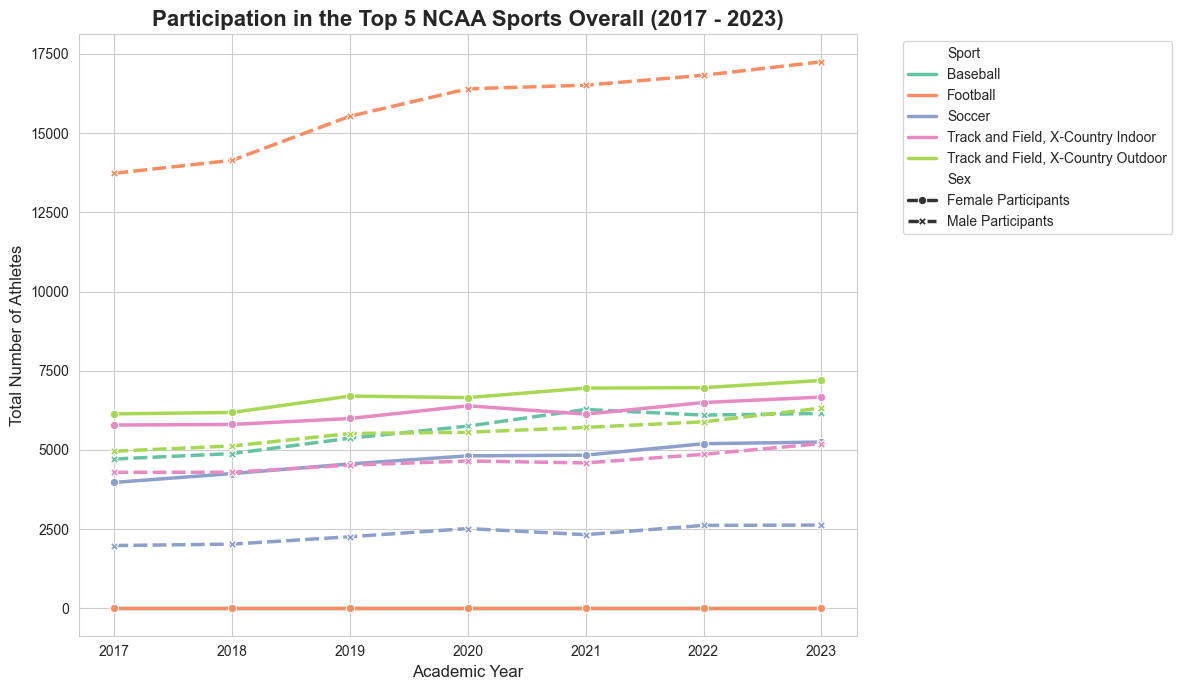

In [2]:
# 1. Load data and exclude 2024
df = pd.read_csv('Athletic Participation Data.csv')
# Exclude 2024 AND exclude any rogue data from before 2017
df = df[(df['Year'] != 2024) & (df['Year'] >= 2017)]

# 2. Find the top 5 sports overall (both men and women combined)
top_5_sports = df.groupby('Sport')['Current Number of Athletes'].sum().nlargest(5).index
df_filtered = df[df['Sport'].isin(top_5_sports)]

# 3. Group the data by year, sex, and sport
# (We keep 'sex' in here in case you want to see the gender split within these top sports)
sports_over_time = df_filtered.groupby(['Year', 'Sex', 'Sport'])['Current Number of Athletes'].sum().reset_index()

# 4. Set up the plot
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# 5. Create the line plot
ax = sns.lineplot(
    data=sports_over_time, 
    x='Year', 
    y='Current Number of Athletes', 
    hue='Sport',       # Splits the lines by sport
    style='Sex',       # Uses different line styles (e.g., solid vs. dashed) for Men vs. Women
    markers=True,
    palette='Set2',    
    linewidth=2.5
)

# 6. Add titles and labels
plt.title("Participation in the Top 5 NCAA Sports Overall (2017 - 2023)", fontsize=16, fontweight='bold')
plt.xlabel("Academic Year", fontsize=12)
plt.ylabel("Total Number of Athletes", fontsize=12)

# Move the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [15]:
import pandas as pd
import numpy as np

# Categorize the sports into "Revenue" and "Non-Revenue"
revenue_sports = ['Football', 'Basketball']

# Create a new column using np.where to assign the category
df['Category'] = np.where(df['Sport'].isin(revenue_sports), 'Revenue Sports', 'Non-Revenue Sports')

# Filter for just the years we want to compare: 2021 (NIL starts) vs 2023
df_comparison = df[df['Year'].isin([2021, 2023])]

# Group by our new category and the year, then sum the athletes
# .unstack() pivots the years into columns so we can easily do math on them
growth_table = df_comparison.groupby(['Category', 'Year'])['Current Number of Athletes'].sum().unstack()

# 5. Calculate the percentage growth between 2021 and 2023
growth_table['Growth (%)'] = ((growth_table[2023] - growth_table[2021]) / growth_table[2021]) * 100

# Format the columns to look clean for your HTML export
growth_table = growth_table.round(2) # Rounds the percentage to 2 decimal places
growth_table.columns.name = None     # Cleans up the header
growth_table.index.name = 'Sport Category'

# Display the final table
print("Growth in NCAA Athlete Participation Pre/Post NIL (2021 vs. 2023)")
print("-" * 65)
print(growth_table)

Growth in NCAA Athlete Participation Pre/Post NIL (2021 vs. 2023)
-----------------------------------------------------------------
                     2021.0   2023.0  Growth (%)
Sport Category                                  
Non-Revenue Sports  67561.0  71998.0        6.57
Revenue Sports      22198.0  23148.0        4.28


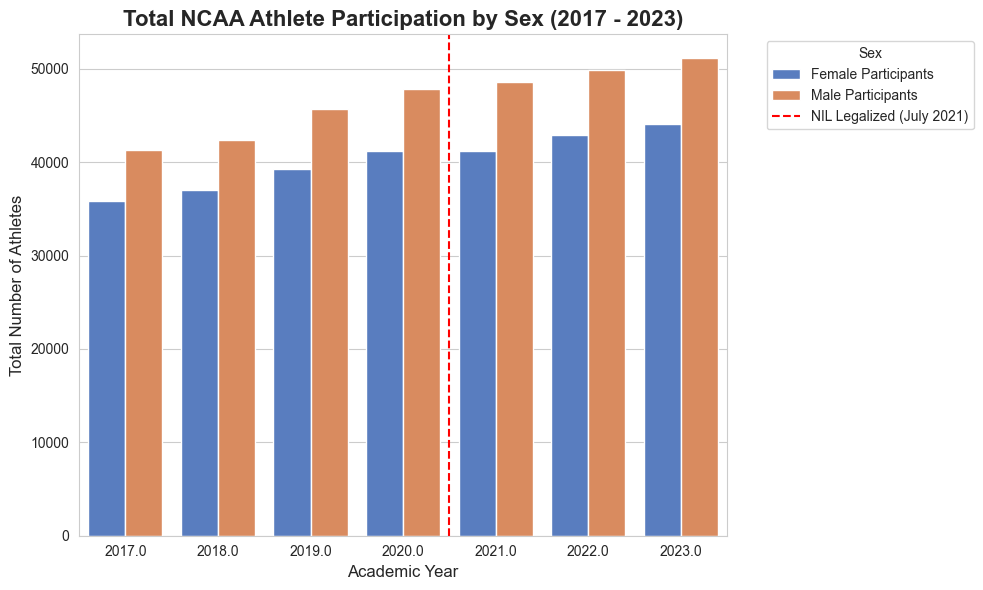

In [18]:

df = df[(df['Year'] != 2024) & (df['Year'] >= 2017)]

# 2. Group the data by 'year' and 'sex' to get total athletes
gender_over_time = df.groupby(['Year', 'Sex'])['Current Number of Athletes'].sum().reset_index()

# 3. Set up the plot
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# 4. Create the Grouped Bar Chart
ax = sns.barplot(
    data=gender_over_time, 
    x='Year', 
    y='Current Number of Athletes', 
    hue='Sex',
    palette='muted' # A clean, professional color palette
)

# 5. Add titles, labels, and the NIL milestone
plt.title("Total NCAA Athlete Participation by Sex (2017 - 2023)", fontsize=16, fontweight='bold')
plt.xlabel("Academic Year", fontsize=12)
plt.ylabel("Total Number of Athletes", fontsize=12)

# Add a vertical line for the NIL ruling (between 2020 and 2021 on a categorical x-axis)
# Since the x-axis is categorical (0=2017, 1=2018, 2=2019, 3=2020, 4=2021), the line goes at 3.5
plt.axvline(x=3.5, color='red', linestyle='--', label='NIL Legalized (July 2021)')

# Adjust the legend
plt.legend(title='Sex', bbox_to_anchor=(1.05, 1), loc='upper left')

# Display the plot
plt.tight_layout()
plt.show()

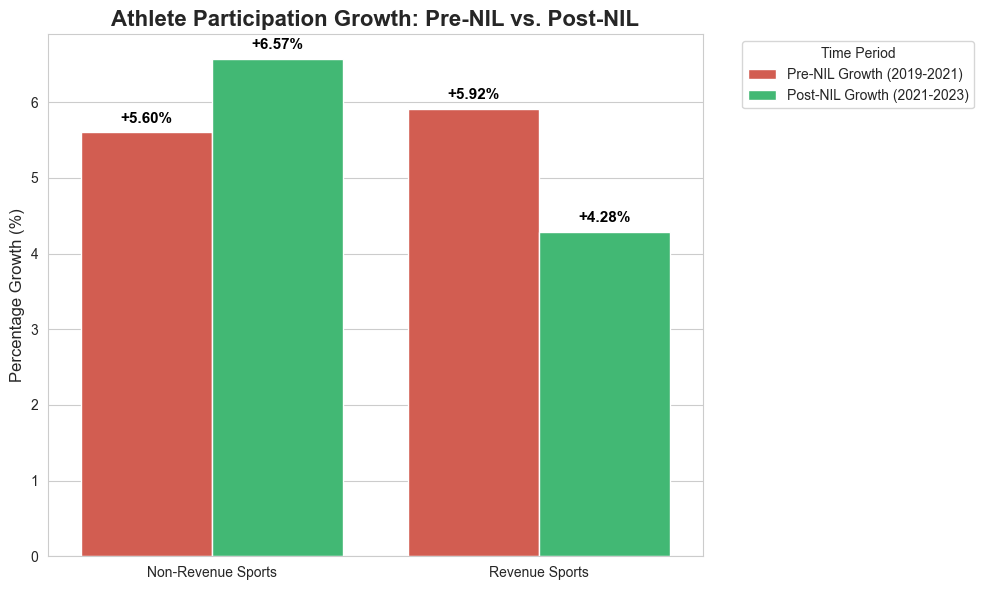

In [20]:
# 1. Categorize the sports
revenue_sports = ['Football', 'Basketball']
df['Category'] = np.where(df['Sport'].isin(revenue_sports), 'Revenue Sports', 'Non-Revenue Sports')

# 2. Filter for the years needed for both growth periods (2019, 2021, 2023)
df_comparison = df[df['Year'].isin([2019, 2021, 2023])]

# 3. Group and pivot to get totals for each year
growth_table = df_comparison.groupby(['Category', 'Year'])['Current Number of Athletes'].sum().unstack()

# 4. Calculate the percentage growth for BOTH periods
growth_table['Pre-NIL Growth (2019-2021)'] = ((growth_table[2021] - growth_table[2019]) / growth_table[2019]) * 100
growth_table['Post-NIL Growth (2021-2023)'] = ((growth_table[2023] - growth_table[2021]) / growth_table[2021]) * 100

# 5. Restructure the data for seaborn (using pandas .melt)
plot_data = growth_table[['Pre-NIL Growth (2019-2021)', 'Post-NIL Growth (2021-2023)']].reset_index()
plot_data = plot_data.melt(id_vars='Category', var_name='Time Period', value_name='Growth (%)')

# 6. Set up the grouped bar plot
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

ax = sns.barplot(
    data=plot_data,
    x='Category',
    y='Growth (%)',
    hue='Time Period',
    palette=['#e74c3c', '#2ecc71'] # Red for Pre-NIL (often negative due to COVID), Green for Post-NIL
)

# 7. Add Titles and Labels
plt.title("Athlete Participation Growth: Pre-NIL vs. Post-NIL", fontsize=16, fontweight='bold')
plt.xlabel("", fontsize=12)
plt.ylabel("Percentage Growth (%)", fontsize=12)

# 8. Add the exact percentages on top of the bars
for p in ax.patches:
    height = p.get_height()
      
    if height == 0:
        continue
        
    # Format the text with a '+' for positive numbers
    text = f"+{height:.2f}%" if height > 0 else f"{height:.2f}%"
    
    ax.annotate(text, 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom' if height > 0 else 'top', 
                fontsize=11, fontweight='bold', color='black', 
                xytext=(0, 5 if height > 0 else -15), textcoords='offset points')
    
# Move legend for a cleaner look
plt.legend(title='Time Period', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()